In [5]:
import pandas as pd

df_316L = pd.read_csv("../data/raw/316L.csv")
df_in718 = pd.read_csv("../data/raw/in718.csv")

df_ti64_ST = pd.read_csv("../data/raw/cmu/ti64_ST.csv")
df_ti64_MT = pd.read_csv("../data/raw/cmu/ti64_MT.csv")
df_ti64_widths = pd.read_csv("../data/raw/cmu/ti64_widths.csv")

print("316L shape:", df_316L.shape)
print("IN718 shape:", df_in718.shape)
print("Ti64 ST shape:", df_ti64_ST.shape)
print("Ti64 MT shape:", df_ti64_MT.shape)
print("Ti64 widths shape:", df_ti64_widths.shape)


316L shape: (90, 23)
IN718 shape: (342, 4)
Ti64 ST shape: (216, 6)
Ti64 MT shape: (410, 7)
Ti64 widths shape: (2160000, 6)


In [6]:
df_316L.columns, df_in718.columns, df_ti64_ST.columns, df_ti64_MT.columns, df_ti64_widths.columns


(Index(['Sample', 'P', 'v', 'w exp', 'd exp', 'R exp', 'Unnamed: 6', 'w model',
        'R model', 'd model', 'Unnamed: 10', 'R error', 'w error', 'd error',
        'Unnamed: 14', 'melting regime', 'Unnamed: 16', 'av.error', 'R', 'w',
        'd', 'Unnamed: 21', 'nb. of samples'],
       dtype='object'),
 Index(['P_W', 'v_mm_per_s', 'melt_depth_um', 'melt_width_um'], dtype='object'),
 Index(['Slice', 'Orientation (degrees)', 'Velocity (mm/s)', 'Width (um)',
        'Depth (um)', 'Cap (um)'],
       dtype='object'),
 Index(['Slice', 'Orientation (degrees)', 'Power (W)', 'Velocity (mm/s)',
        'Width (um)', 'Depth (um)', 'Cap (um)'],
       dtype='object'),
 Index(['Unnamed: 0', 'Width (um)', 'Location (um)', 'Orientation (degrees)',
        'Velocity (mm/s)', 'Power (W)'],
       dtype='object'))

In [7]:
import pandas as pd

# --------------------------
# Clean 316L
# --------------------------
df316 = df_316L.copy()

df316_clean = df316[["P", "v", "w exp", "d exp"]].rename(columns={
    "P": "P_W",
    "v": "v_mm_per_s",
    "w exp": "melt_width_um",
    "d exp": "melt_depth_um"
})

df316_clean["material"] = "316L"

# --------------------------
# Clean IN718
# --------------------------
df_in718_clean = df_in718.copy()
df_in718_clean["material"] = "IN718"

# --------------------------
# Clean Ti64 (ST + MT)
# --------------------------

# ST file (no power column)
df_ti64_ST_clean = df_ti64_ST.rename(columns={
    "Velocity (mm/s)": "v_mm_per_s",
    "Width (um)": "melt_width_um",
    "Depth (um)": "melt_depth_um"
})

# Assign assumed power for ST dataset
df_ti64_ST_clean["P_W"] = 200  # temporary assumption, adjust if needed
df_ti64_ST_clean["material"] = "Ti64"

# MT file (has power)
df_ti64_MT_clean = df_ti64_MT.rename(columns={
    "Power (W)": "P_W",
    "Velocity (mm/s)": "v_mm_per_s",
    "Width (um)": "melt_width_um",
    "Depth (um)": "melt_depth_um"
})
df_ti64_MT_clean["material"] = "Ti64"

# Merge ST + MT
df_ti64_clean = pd.concat([df_ti64_ST_clean[["material","P_W","v_mm_per_s","melt_width_um","melt_depth_um"]],
                           df_ti64_MT_clean[["material","P_W","v_mm_per_s","melt_width_um","melt_depth_um"]]],
                           ignore_index=True)

# --------------------------
# Save to data/clean
# --------------------------
df316_clean.to_csv("../data/clean/316L_clean.csv", index=False)
df_in718_clean.to_csv("../data/clean/IN718_clean.csv", index=False)
df_ti64_clean.to_csv("../data/clean/Ti64_clean.csv", index=False)

df316_clean.shape, df_in718_clean.shape, df_ti64_clean.shape


((90, 5), (342, 5), (626, 5))

In [8]:
import pandas as pd

master = pd.concat(
    [
        df316_clean[["material", "P_W", "v_mm_per_s", "melt_width_um", "melt_depth_um"]],
        df_in718_clean[["material", "P_W", "v_mm_per_s", "melt_width_um", "melt_depth_um"]],
        df_ti64_clean[["material", "P_W", "v_mm_per_s", "melt_width_um", "melt_depth_um"]],
    ],
    ignore_index=True
)

master.shape, master["material"].value_counts()


((1058, 5),
 material
 Ti64     626
 IN718    342
 316L      90
 Name: count, dtype: int64)

In [9]:
numeric_cols = ["P_W", "v_mm_per_s", "melt_width_um", "melt_depth_um"]

for col in numeric_cols:
    master[col] = pd.to_numeric(master[col], errors="coerce")

master.dtypes


material          object
P_W              float64
v_mm_per_s       float64
melt_width_um    float64
melt_depth_um    float64
dtype: object

In [10]:
before = master.shape[0]

master = master.dropna(subset=["P_W", "v_mm_per_s", "melt_width_um", "melt_depth_um"])

after = master.shape[0]

before, after


(1058, 1012)

In [11]:
master.to_csv("../data/clean/meltpool_master.csv", index=False)


In [12]:
master.columns.tolist()


['material', 'P_W', 'v_mm_per_s', 'melt_width_um', 'melt_depth_um']

In [13]:
df316_clean.shape, df_in718_clean.shape, df_ti64_clean.shape


((90, 5), (342, 5), (626, 5))

In [14]:
master["LED_J_per_mm"] = master["P_W"] / master["v_mm_per_s"]


In [15]:
master["norm_width"] = master["melt_width_um"] / master["melt_width_um"].max()
master["norm_depth"] = master["melt_depth_um"] / master["melt_depth_um"].max()


In [16]:
master.head()
master.shape


(1012, 8)

In [17]:
master.describe()


,P_W,v_mm_per_s,melt_width_um,melt_depth_um,LED_J_per_mm,norm_width,norm_depth
count,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000,1012.000000
mean,314.426877,1197.332016,182.776711,232.040746,0.323455,0.558380,0.189267
std,112.380798,421.219787,54.578462,211.139836,0.252748,0.166736,0.172218
min,100.000000,400.000000,56.000000,14.000000,0.090909,0.171079,0.011419
25%,200.000000,800.000000,138.634950,104.690475,0.166667,0.423527,0.085392
50%,370.000000,1350.000000,179.784000,150.327800,0.246667,0.549237,0.122616
75%,370.000000,1550.000000,226.023000,261.628000,0.333333,0.690497,0.213400
max,600.000000,1700.000000,327.334000,1226.000000,1.500000,1.000000,1.000000


In [18]:
# Hatch spacing (h) and layer thickness (t) in MILLIMETERS
hatch_map_mm = {
    "Ti64": 0.10,    # 100 µm
    "316L": 0.11,    # 110 µm
    "IN718": 0.11,   # 110 µm
}

thickness_map_mm = {
    "Ti64": 0.03,    # 30 µm
    "316L": 0.04,    # 40 µm
    "IN718": 0.04,   # 40 µm
}

# Add columns based on material
master["h_mm"] = master["material"].map(hatch_map_mm)
master["t_mm"] = master["material"].map(thickness_map_mm)


In [19]:
master["VED_J_per_mm3"] = master["P_W"] / (
    master["v_mm_per_s"] * master["h_mm"] * master["t_mm"]
)


In [20]:
master["VED_J_per_mm3"].describe()


count    1012.000000
mean       87.227194
std        53.132773
min        20.661157
25%        49.382716
50%        78.326613
75%        91.358025
max       340.909091
Name: VED_J_per_mm3, dtype: float64

In [21]:
import numpy as np

invalid_ved = master[
    (master["VED_J_per_mm3"].isna()) |
    (~np.isfinite(master["VED_J_per_mm3"])) |
    (master["VED_J_per_mm3"] <= 0)
]

invalid_ved


,material,P_W,v_mm_per_s,melt_width_um,melt_depth_um,LED_J_per_mm,norm_width,norm_depth,h_mm,t_mm,VED_J_per_mm3


In [22]:
master.groupby("material")[["h_mm", "t_mm"]].first()


,h_mm,t_mm
material,,
316L,0.11,0.04
IN718,0.11,0.04
Ti64,0.10,0.03


In [23]:
master[["P_W", "v_mm_per_s", "h_mm", "t_mm", "VED_J_per_mm3"]].head()


,P_W,v_mm_per_s,h_mm,t_mm,VED_J_per_mm3
0,100.0,400.0,0.11,0.04,56.818182
1,100.0,500.0,0.11,0.04,45.454545
2,100.0,600.0,0.11,0.04,37.878788
3,100.0,700.0,0.11,0.04,32.467532
4,100.0,800.0,0.11,0.04,28.409091


In [24]:
master.to_csv("../data/clean/meltpool_master_with_VED.csv", index=False)


In [25]:
import numpy as np
import pandas as pd

# 1. Map material → integer ID
material_map = {
    "316L": 0,
    "IN718": 1,
    "Ti64": 2,
}

master["material_id"] = master["material"].map(material_map)

# Sanity check
print(master[["material", "material_id"]].drop_duplicates())


    material  material_id
0       316L            0
90     IN718            1
432     Ti64            2


In [26]:
# 2. Numeric process/physics features (no one-hot here!)
numeric_feature_cols = [
    "P_W",
    "v_mm_per_s",
    "h_mm",
    "t_mm",
    "LED_J_per_mm",
    "VED_J_per_mm3",
]

target_cols = ["melt_width_um", "melt_depth_um"]

# 3. Build numpy arrays
X_num = master[numeric_feature_cols].values          # shape (N, 6)
mat_id = master["material_id"].values               # shape (N,)
y = master[target_cols].values                      # shape (N, 2)

X_num.shape, mat_id.shape, y.shape


((1012, 6), (1012,), (1012, 2))

In [27]:
master[numeric_feature_cols + ["material", "material_id"] + target_cols].head()


,P_W,v_mm_per_s,h_mm,t_mm,LED_J_per_mm,VED_J_per_mm3,material,material_id,melt_width_um,melt_depth_um
0,100.0,400.0,0.11,0.04,0.250000,56.818182,316L,0,119.714286,129.285714
1,100.0,500.0,0.11,0.04,0.200000,45.454545,316L,0,109.714286,98.857143
2,100.0,600.0,0.11,0.04,0.166667,37.878788,316L,0,100.285714,75.142857
3,100.0,700.0,0.11,0.04,0.142857,32.467532,316L,0,79.000000,49.142857
4,100.0,800.0,0.11,0.04,0.125000,28.409091,316L,0,80.142857,47.571429


In [29]:
master[numeric_feature_cols + ["material", "material_id"] + target_cols].style.set_properties(**{'max-height': '300px', 'overflow-y': 'scroll'})


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Split into train/test
X_num_train, X_num_test, mat_id_train, mat_id_test, y_train, y_test = train_test_split(
    X_num,
    mat_id,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)

X_num_train.shape, X_num_test.shape, mat_id_train.shape, y_train.shape


((809, 6), (203, 6), (809,), (809, 2))

In [32]:
scaler = StandardScaler()
X_num_train_scaled = scaler.fit_transform(X_num_train)
X_num_test_scaled = scaler.transform(X_num_test)

# Quick check
X_num_train_scaled[:3], X_num_test_scaled[:3]


(array([[ 0.50690827,  0.71304022, -0.78612976, -0.78612976, -0.30070137,
         -0.08587709],
        [ 0.50690827,  0.83115028, -0.78612976, -0.78612976, -0.3327722 ,
         -0.13674875],
        [ 0.50690827,  0.71304022, -0.78612976, -0.78612976, -0.30070137,
         -0.08587709]]),
 array([[ 0.50690827,  0.4768201 , -0.78612976, -0.78612976, -0.22968738,
          0.02676732],
        [ 0.50690827,  0.83115028, -0.78612976, -0.78612976, -0.3327722 ,
         -0.13674875],
        [ 0.50690827,  0.83115028, -0.78612976, -0.78612976, -0.3327722 ,
         -0.13674875]]))

In [33]:
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Convert to tensors
X_num_train_t = torch.tensor(X_num_train_scaled, dtype=torch.float32)
X_num_test_t  = torch.tensor(X_num_test_scaled, dtype=torch.float32)

mat_id_train_t = torch.tensor(mat_id_train, dtype=torch.long)
mat_id_test_t  = torch.tensor(mat_id_test, dtype=torch.long)

y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.float32)

X_num_train_t.shape, mat_id_train_t.shape, y_train_t.shape


(torch.Size([809, 6]), torch.Size([809]), torch.Size([809, 2]))

In [34]:
class MeltPoolDataset(Dataset):
    def __init__(self, X_num, mat_id, y):
        self.X_num = X_num
        self.mat_id = mat_id
        self.y = y

    def __len__(self):
        return self.X_num.shape[0]

    def __getitem__(self, idx):
        return {
            "X_num": self.X_num[idx],
            "mat_id": self.mat_id[idx],
            "y": self.y[idx],
        }

train_ds = MeltPoolDataset(X_num_train_t, mat_id_train_t, y_train_t)
test_ds  = MeltPoolDataset(X_num_test_t, mat_id_test_t, y_test_t)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)


In [50]:
import torch
import torch.nn as nn

class MeltPoolSurrogate(nn.Module):
    def __init__(
        self,
        num_numeric_features: int,
        num_materials: int = 3,
        emb_dim: int = 3,
        hidden_sizes=(64, 64),
        dropout: float = 0.10,   # <--- NEW: dropout rate
    ):
        super().__init__()

        # Embedding: maps material_id (0,1,2) → vector of size emb_dim
        self.material_emb = nn.Embedding(num_materials, emb_dim)

        # MLP that takes [numeric_features + embedding] as input
        layers = []
        input_dim = num_numeric_features + emb_dim

        in_dim = input_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_dim, h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))   # <--- NEW: dropout after each hidden layer
            in_dim = h

        # Final layer: predict width & depth (2 outputs)
        layers.append(nn.Linear(in_dim, 2))

        self.mlp = nn.Sequential(*layers)

    def forward(self, X_num, mat_id):
        """
        X_num: tensor of shape (batch_size, num_numeric_features)
        mat_id: tensor of shape (batch_size,) with values 0,1,2
        """
        # Get embedding for each material id → (batch_size, emb_dim)
        mat_vec = self.material_emb(mat_id)

        # Concatenate numeric features + material embedding
        x = torch.cat([X_num, mat_vec], dim=1)

        # Pass through MLP
        y_pred = self.mlp(x)
        return y_pred


In [51]:
### Improved Training Loop (Early Stopping + Dropout + L2 + Checkpoint)

In [52]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# ---- DEVICE ----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# ---- MODEL ----
model = MeltPoolSurrogate(
    num_numeric_features=X_train_num.shape[1],
    num_materials=3,
    emb_dim=3,
    hidden_sizes=(64, 64),
    dropout=0.10                # <--- Dropout activated
).to(device)

# ---- OPTIMIZER with L2 REGULARIZATION ----
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4           # <--- L2 regularization
)

criterion = nn.MSELoss()

# ---- DATALOADERS ----
train_dataset = TensorDataset(X_train_num, X_train_mat, y_train)
val_dataset   = TensorDataset(X_val_num, X_val_mat, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

# ---- EARLY STOPPING SETTINGS ----
best_val_loss = float("inf")
patience = 20
patience_counter = 0
checkpoint_path = "best_surrogate.pt"

# ---- TRAINING LOOP ----
train_losses = []
val_losses = []

epochs = 200

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    # TRAINING
    for xb_num, xb_mat, yb in train_loader:
        xb_num = xb_num.to(device)
        xb_mat = xb_mat.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        preds = model(xb_num, xb_mat)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

    train_loss = running_train_loss / len(train_loader)
    train_losses.append(train_loss)

    # VALIDATION
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb_num, xb_mat, yb in val_loader:
            xb_num = xb_num.to(device)
            xb_mat = xb_mat.to(device)
            yb = yb.to(device)

            preds = model(xb_num, xb_mat)
            val_loss = criterion(preds, yb)
            running_val_loss += val_loss.item()

    val_loss = running_val_loss / len(val_loader)
    val_losses.append(val_loss)

    # ----- EARLY STOPPING + CHECKPOINTING -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"Epoch {epoch:03d} | NEW BEST Val Loss: {val_loss:.4f} | Saved!")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("\nEarly stopping triggered.")
        break

    print(f"Epoch {epoch:03d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

print("\nTraining finished.")
print(f"Best Validation Loss: {best_val_loss:.4f}")


Using device: cpu


NameError: name 'X_train_num' is not defined

In [36]:
num_numeric_features = X_num_train_t.shape[1]  # should be 6
model = MeltPoolSurrogate(num_numeric_features=num_numeric_features, num_materials=3, emb_dim=3)

print(model)


MeltPoolSurrogate(
  (material_emb): Embedding(3, 3)
  (mlp): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [37]:
for name, param in model.named_parameters():
    if "material_emb" in name:
        print(name, param.shape)


material_emb.weight torch.Size([3, 3])


In [38]:
import torch.nn as nn
import torch.optim as optim

# Loss function: MSE (standard for regression)
criterion = nn.MSELoss()

# Optimizer: Adam (works well for surrogates)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Optional: learning rate scheduler (good for stability)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)


/home/vscode/.local/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [39]:
def train_epoch(model, loader, criterion, optimizer, device="cpu"):
    model.train()
    running_loss = 0.0

    for batch in loader:
        X_num = batch["X_num"].to(device)
        mat_id = batch["mat_id"].to(device)
        y_true = batch["y"].to(device)

        optimizer.zero_grad()

        y_pred = model(X_num, mat_id)
        loss = criterion(y_pred, y_true)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_num.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


def eval_epoch(model, loader, criterion, device="cpu"):
    model.eval()
    running_loss = 0.0

    with torch.no_grad():
        for batch in loader:
            X_num = batch["X_num"].to(device)
            mat_id = batch["mat_id"].to(device)
            y_true = batch["y"].to(device)

            y_pred = model(X_num, mat_id)
            loss = criterion(y_pred, y_true)

            running_loss += loss.item() * X_num.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss


In [48]:
num_epochs = 150
device = "cpu"  # change to "cuda" if GPU is available

model.to(device)

train_history = []
val_history = []

best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = eval_epoch(model, test_loader, criterion, device)

    # Record loss for plotting
    train_history.append(train_loss)
    val_history.append(val_loss)

    # Scheduler step (optional)
    scheduler.step(val_loss)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_meltpool_surrogate.pt")

    # Print every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

print("Training complete.")
print(f"Best validation loss: {best_val_loss:.4f}")


Epoch 000 | Train Loss: 1675.5803 | Val Loss: 2150.1824
Epoch 010 | Train Loss: 1666.5937 | Val Loss: 2149.5927
Epoch 020 | Train Loss: 1655.8327 | Val Loss: 2130.5104
Epoch 030 | Train Loss: 1650.7072 | Val Loss: 2122.2943
Epoch 040 | Train Loss: 1647.7195 | Val Loss: 2117.7238
Epoch 050 | Train Loss: 1637.8883 | Val Loss: 2113.1355
Epoch 060 | Train Loss: 1634.7041 | Val Loss: 2120.6254
Epoch 070 | Train Loss: 1624.6305 | Val Loss: 2114.7712
Epoch 080 | Train Loss: 1613.0353 | Val Loss: 2094.5126
Epoch 090 | Train Loss: 1613.2434 | Val Loss: 2086.2649
Epoch 100 | Train Loss: 1609.7803 | Val Loss: 2084.0959
Epoch 110 | Train Loss: 1601.6434 | Val Loss: 2069.8656
Epoch 120 | Train Loss: 1597.9984 | Val Loss: 2071.6553
Epoch 130 | Train Loss: 1595.1446 | Val Loss: 2067.6347
Epoch 140 | Train Loss: 1593.7235 | Val Loss: 2069.2578
Training complete.
Best validation loss: 2060.7954


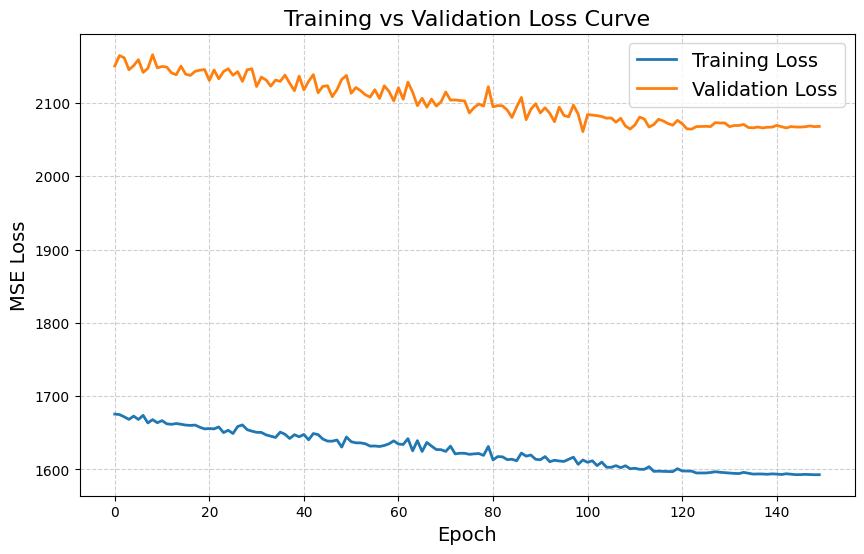

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(train_history, label="Training Loss", linewidth=2)
plt.plot(val_history, label="Validation Loss", linewidth=2)

plt.title("Training vs Validation Loss Curve", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("MSE Loss", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=14)
plt.show()


In [41]:
import torch
torch.cuda.is_available()


False

In [42]:
import os
os.path.isfile("best_meltpool_surrogate.pt")


True

In [43]:
model.eval()  # evaluation mode

with torch.no_grad():
    y_pred_test = model(X_num_test_t, mat_id_test_t).numpy()

y_true_test = y_test  # numpy version already


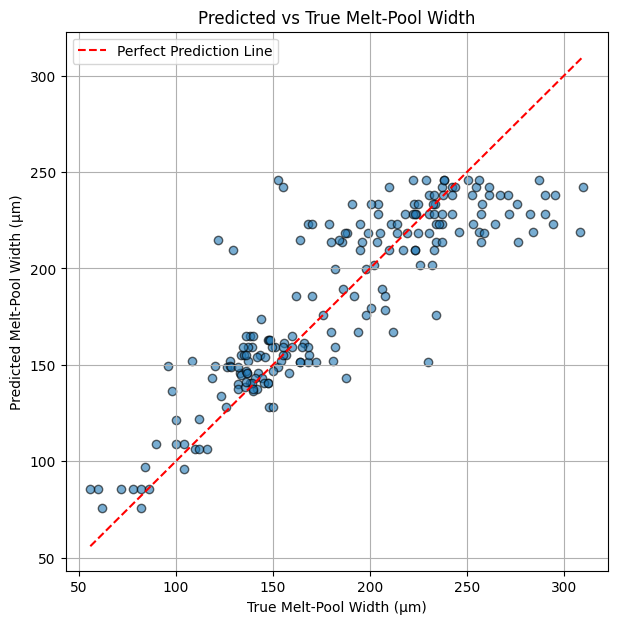

In [44]:
import matplotlib.pyplot as plt
import numpy as np

true_width = y_true_test[:, 0]
pred_width = y_pred_test[:, 0]

plt.figure(figsize=(7, 7))
plt.scatter(true_width, pred_width, alpha=0.6, edgecolor='black')
plt.plot([true_width.min(), true_width.max()],
         [true_width.min(), true_width.max()],
         'r--', label='Perfect Prediction Line')

plt.xlabel("True Melt-Pool Width (µm)")
plt.ylabel("Predicted Melt-Pool Width (µm)")
plt.title("Predicted vs True Melt-Pool Width")
plt.legend()
plt.grid(True)
plt.show()


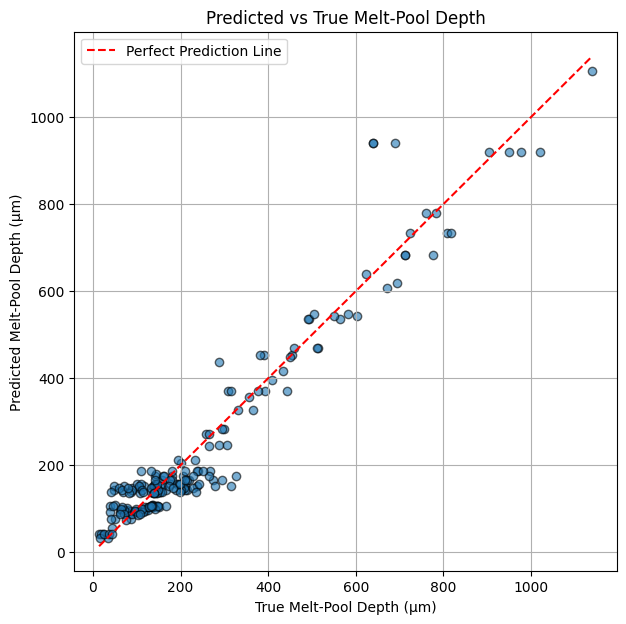

In [45]:
true_depth = y_true_test[:, 1]
pred_depth = y_pred_test[:, 1]

plt.figure(figsize=(7, 7))
plt.scatter(true_depth, pred_depth, alpha=0.6, edgecolor='black')
plt.plot([true_depth.min(), true_depth.max()],
         [true_depth.min(), true_depth.max()],
         'r--', label='Perfect Prediction Line')

plt.xlabel("True Melt-Pool Depth (µm)")
plt.ylabel("Predicted Melt-Pool Depth (µm)")
plt.title("Predicted vs True Melt-Pool Depth")
plt.legend()
plt.grid(True)
plt.show()


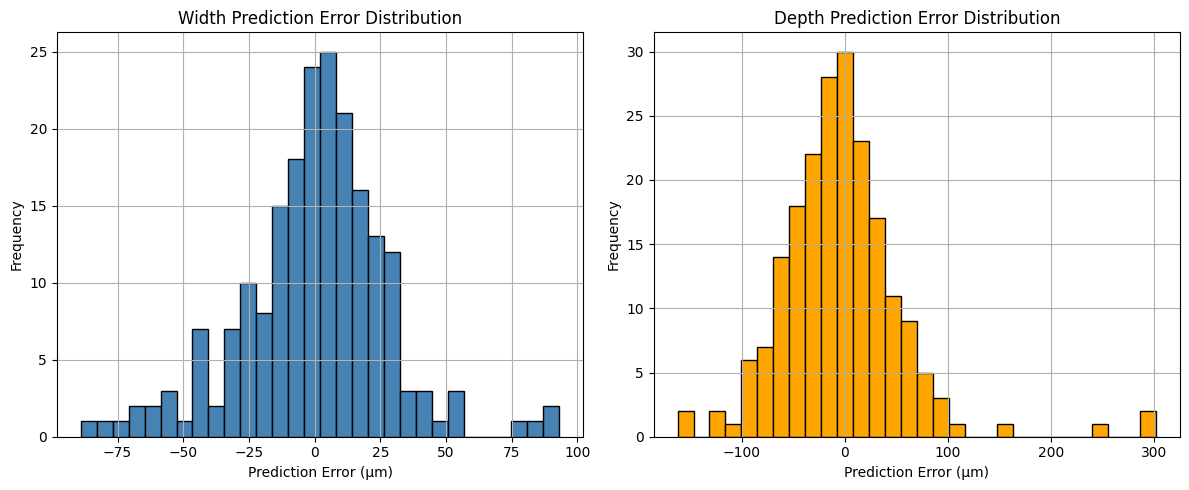

In [46]:
width_error = pred_width - true_width
depth_error = pred_depth - true_depth

plt.figure(figsize=(12, 5))

# Width Errors
plt.subplot(1, 2, 1)
plt.hist(width_error, bins=30, color='steelblue', edgecolor='black')
plt.title("Width Prediction Error Distribution")
plt.xlabel("Prediction Error (µm)")
plt.ylabel("Frequency")
plt.grid(True)

# Depth Errors
plt.subplot(1, 2, 2)
plt.hist(depth_error, bins=30, color='orange', edgecolor='black')
plt.title("Depth Prediction Error Distribution")
plt.xlabel("Prediction Error (µm)")
plt.ylabel("Frequency")
plt.grid(True)

plt.tight_layout()
plt.show()


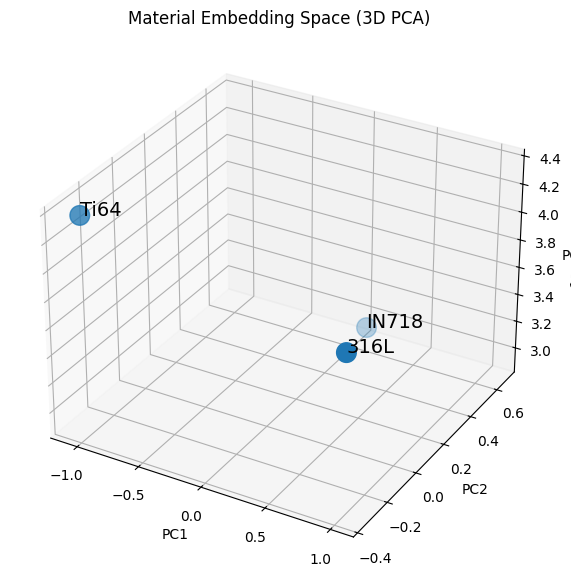

In [47]:
from sklearn.decomposition import PCA

# Extract embedding weights
embeddings = model.material_emb.weight.detach().numpy()
materials = ["316L", "IN718", "Ti64"]

# PCA to 3D for visualization
pca = PCA(n_components=3)
emb_3d = pca.fit_transform(embeddings)

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(emb_3d[:, 0], emb_3d[:, 1], emb_3d[:, 2], s=200)

for i, mat in enumerate(materials):
    ax.text(emb_3d[i, 0], emb_3d[i, 1], emb_3d[i, 2], mat, fontsize=14)

ax.set_title("Material Embedding Space (3D PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.show()
